# Section 1 — Kaggle Setup & Imports

In [7]:
import os, random, json, shutil
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from tqdm import tqdm
from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report, precision_recall_fscore_support
import torch, torch.nn as nn, torch.optim as optim, torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import transforms

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.benchmark = True
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

ADNI_DIR = None
for root, dirs, files in os.walk('/kaggle/input'):
    if 'CN' in dirs and 'MCI' in dirs and 'AD' in dirs:
        ADNI_DIR = root
        break
if ADNI_DIR is None:
    raise RuntimeError("Could not find ADNI dataset in /kaggle/input.")
print(f"ADNI_DIR found: {ADNI_DIR}")

Using device: cuda
ADNI_DIR found: /kaggle/input/datasets/omr0zyd/dataset/adni_nifti_preprocessed


# Section 2 — Configuration

In [8]:
DATA_ROOT  = ADNI_DIR
OUTPUT_DIR = "/kaggle/working/preprocessed"
CKPT_DIR   = "/kaggle/working/checkpoints"
os.makedirs(CKPT_DIR, exist_ok=True)

IMAGE_SIZE   = 128
TRAIN_RATIO  = 0.80
BATCH_SIZE   = 32
NUM_EPOCHS   = 40
LR           = 1e-3
WEIGHT_DECAY = 1e-4
PATIENCE     = 8
GRAD_CLIP    = 1.0

CONV_FILTERS = [32, 64, 128, 256, 512]
SE_RATIO     = 16
DROPOUT      = 0.3
RF_TREES     = 100

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]
VALID_EXTS = {'.jpg', '.jpeg', '.png', '.bmp', '.tif', '.tiff'}

# Section 3 — Data Loading & Splitting (Slice-Level)

In [9]:
all_paths = []
all_labels = []

CLASS_NAMES = sorted([
    d for d in os.listdir(DATA_ROOT)
    if os.path.isdir(os.path.join(DATA_ROOT, d))
])
print(f"Classes found: {CLASS_NAMES}")
print(f"Number of classes: {len(CLASS_NAMES)}")

for label_idx, class_name in enumerate(CLASS_NAMES):
    class_dir = os.path.join(DATA_ROOT, class_name)
    for root, _, files in os.walk(class_dir):
        for file in files:
            if os.path.splitext(file)[1].lower() in VALID_EXTS:
                all_paths.append(os.path.join(root, file))
                all_labels.append(label_idx)

print(f"Total slices found: {len(all_paths)}")

train_paths, temp_paths, train_labels, temp_labels = train_test_split(
    all_paths, all_labels,
    test_size=1 - TRAIN_RATIO,
    stratify=all_labels,
    random_state=SEED,
)

val_paths, test_paths, val_labels, test_labels = train_test_split(
    temp_paths, temp_labels,
    test_size=0.5,
    stratify=temp_labels,
    random_state=SEED,
)

print(f"\nSplits:")
print(f"Train: {len(train_paths)} | Val: {len(val_paths)} | Test: {len(test_paths)}")

for name, lbls in [("Train", train_labels), ("Val", val_labels), ("Test", test_labels)]:
    c = Counter(lbls)
    print(f"  {name} class distribution: {dict(sorted(c.items()))}")

Classes found: ['AD', 'CN', 'MCI']
Number of classes: 3
Total slices found: 8512

Splits:
Train: 6809 | Val: 851 | Test: 852
  Train class distribution: {0: 1147, 1: 1873, 2: 3789}
  Val class distribution: {0: 143, 1: 234, 2: 474}
  Test class distribution: {0: 144, 1: 234, 2: 474}


# Section 4 — Preprocessing (128x128)

In [10]:
if os.path.exists(OUTPUT_DIR):
    shutil.rmtree(OUTPUT_DIR)
os.makedirs(OUTPUT_DIR, exist_ok=True)

filename_usage = {}

def save_tensors(paths, labels, split_name):
    split_dir = os.path.join(OUTPUT_DIR, split_name)
    for class_name in CLASS_NAMES:
        os.makedirs(os.path.join(split_dir, class_name), exist_ok=True)

    for path, label in tqdm(zip(paths, labels), total=len(paths), desc=f"Saving {split_name}"):
        class_name = CLASS_NAMES[label]
        base_name = os.path.basename(path)
        name_only, ext = os.path.splitext(base_name)

        if base_name in filename_usage:
            filename_usage[base_name] += 1
            new_name = f"{name_only}_dup{filename_usage[base_name]}.pt"
        else:
            filename_usage[base_name] = 0
            new_name = f"{name_only}.pt"

        out_path = os.path.join(split_dir, class_name, new_name)

        img = Image.open(path).convert("RGB")
        img = img.resize((IMAGE_SIZE, IMAGE_SIZE))
        tensor = transforms.ToTensor()(img)
        tensor = (tensor * 255).byte()
        torch.save(tensor, out_path)

save_tensors(train_paths, train_labels, "train")
save_tensors(val_paths, val_labels, "val")
save_tensors(test_paths, test_labels, "test")
print("Preprocessing complete.")

Saving test: 100%|██████████| 852/852 [00:08<00:00, 97.54it/s] 

Preprocessing complete.


# Section 5 — Dataset Class & Sampler

In [11]:
normalize = transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)

train_augment = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(p=0.3),
    transforms.RandomRotation(degrees=15),
    transforms.RandomAffine(degrees=0, translate=(0.08, 0.08), scale=(0.9, 1.1), shear=5),
    transforms.ColorJitter(brightness=(0.7, 1.3), contrast=(0.8, 1.2)),
    transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 1.0)),
])

class AlzheimerDataset(Dataset):
    def __init__(self, split_dir, class_names, augment=False):
        self.samples = []
        self.augment = augment
        for label_idx, class_name in enumerate(class_names):
            class_dir = os.path.join(split_dir, class_name)
            if not os.path.exists(class_dir): continue
            for file in os.listdir(class_dir):
                if file.endswith('.pt'):
                    self.samples.append((os.path.join(class_dir, file), label_idx))

    def __len__(self): return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        tensor = torch.load(path, weights_only=True).float() / 255.0
        if self.augment:
            tensor = train_augment(tensor)
        return normalize(tensor), label

    def get_labels(self):
        return [s[1] for s in self.samples]

train_ds = AlzheimerDataset(os.path.join(OUTPUT_DIR, "train"), CLASS_NAMES, augment=True)
val_ds   = AlzheimerDataset(os.path.join(OUTPUT_DIR, "val"), CLASS_NAMES)
test_ds  = AlzheimerDataset(os.path.join(OUTPUT_DIR, "test"), CLASS_NAMES)

train_labels_list = train_ds.get_labels()
class_counts = Counter(train_labels_list)
print(f"\nTraining class distribution: {dict(sorted(class_counts.items()))}")

sample_weights = [1.0 / class_counts[label] for label in train_labels_list]
sampler = WeightedRandomSampler(sample_weights, len(sample_weights), replacement=True)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, sampler=sampler, num_workers=4, pin_memory=True)
val_loader   = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=4, pin_memory=True)
test_loader  = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=4, pin_memory=True)


Training class distribution: {0: 1147, 1: 1873, 2: 3789}


# Section 6 — SECNN Architecture (GroupNorm + Kaiming Init)

In [12]:
class SEBlock(nn.Module):
    def __init__(self, channels, ratio=16):
        super().__init__()
        mid = max(channels // ratio, 1)
        self.squeeze = nn.AdaptiveAvgPool2d(1)
        self.excitation = nn.Sequential(
            nn.Linear(channels, mid, bias=False),
            nn.ReLU(inplace=True),
            nn.Linear(mid, channels, bias=False),
            nn.Sigmoid()
        )
    def forward(self, x):
        b, c, _, _ = x.size()
        w = self.squeeze(x).view(b, c)
        w = self.excitation(w).view(b, c, 1, 1)
        return x * w

class SEConvBlock(nn.Module):
    """Conv -> GroupNorm -> ReLU -> SE -> MaxPool

    GroupNorm instead of BatchNorm:
    - Normalizes within groups of channels PER SAMPLE
    - NOT affected by batch composition (WeightedRandomSampler safe)
    - No running mean/var to go stale between train and val
    """
    def __init__(self, in_ch, out_ch, se_ratio=16):
        super().__init__()
        self.conv = nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1)
        self.gn = nn.GroupNorm(num_groups=min(32, out_ch), num_channels=out_ch)
        self.se = SEBlock(out_ch, ratio=se_ratio)
        self.pool = nn.MaxPool2d(2, 2)
    def forward(self, x):
        x = F.relu(self.gn(self.conv(x)))
        x = self.se(x)
        x = self.pool(x)
        return x

class SECNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        filters = CONV_FILTERS
        in_channels = [3] + filters[:-1]
        self.blocks = nn.ModuleList([
            SEConvBlock(inc, outc, SE_RATIO)
            for inc, outc in zip(in_channels, filters)
        ])
        self.gap = nn.AdaptiveAvgPool2d(1)
        self.flatten = nn.Flatten()
        self.feat_dim = filters[-1]
        self.drop = nn.Dropout(p=DROPOUT)
        self.head = nn.Linear(self.feat_dim, num_classes)

        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
                if m.bias is not None: nn.init.zeros_(m.bias)
            elif isinstance(m, (nn.GroupNorm, nn.BatchNorm2d)):
                nn.init.ones_(m.weight)
                nn.init.zeros_(m.bias)
            elif isinstance(m, nn.Linear):
                nn.init.xavier_normal_(m.weight)
                if m.bias is not None: nn.init.zeros_(m.bias)

    def extract_features(self, x):
        for block in self.blocks: x = block(x)
        x = self.gap(x)
        return self.flatten(x)

    def forward(self, x):
        feats = self.extract_features(x)
        return self.head(self.drop(feats))

model = SECNN(num_classes=len(CLASS_NAMES)).to(device)
total_p = sum(p.numel() for p in model.parameters())
print(f"SECNN built: {total_p:,} params | feat_dim={model.feat_dim} | Head: {len(CLASS_NAMES)} classes")
print(f"  Normalization: GroupNorm (sampler-safe)")
print(f"  Init: Kaiming (conv) + Xavier (linear)")

SECNN built: 1,615,747 params | feat_dim=512 | Head: 3 classes
  Normalization: GroupNorm (sampler-safe)
  Init: Kaiming (conv) + Xavier (linear)


# Section 7 — Training SECNN

In [13]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

warmup_epochs = 3
def lr_lambda(epoch):
    if epoch < warmup_epochs:
        return (epoch + 1) / warmup_epochs
    return 0.5 * (1 + np.cos(np.pi * (epoch - warmup_epochs) / (NUM_EPOCHS - warmup_epochs)))
scheduler = optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)

def run_epoch(loader, model, criterion, optimizer=None, desc=""):
    is_train = optimizer is not None
    model.train() if is_train else model.eval()
    total_loss, correct, total = 0.0, 0, 0
    all_preds, all_labels = [], []

    ctx = torch.enable_grad() if is_train else torch.no_grad()
    with ctx:
        for images, labels in tqdm(loader, desc=desc, leave=False):
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            outputs = model(images)
            loss = criterion(outputs, labels)

            if torch.isnan(loss): continue
            if is_train:
                optimizer.zero_grad()
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
                optimizer.step()

            preds = outputs.argmax(1)
            correct += (preds == labels).sum().item()
            total_loss += loss.item() * labels.size(0)
            total += labels.size(0)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    return total_loss / total, correct / total, all_preds, all_labels

best_val_loss = float('inf')
patience_ctr = 0
ckpt_path = os.path.join(CKPT_DIR, "best_secnn_multiclass.pt")

for epoch in range(1, NUM_EPOCHS + 1):
    tr_loss, tr_acc, _, _ = run_epoch(train_loader, model, criterion, optimizer, desc=f"Ep{epoch}")
    vl_loss, vl_acc, _, _ = run_epoch(val_loader, model, criterion, desc=f"Val{epoch}")
    scheduler.step()
    lr_now = optimizer.param_groups[0]['lr']
    print(f"  Ep {epoch:02d} | trn {tr_loss:.4f}/{tr_acc*100:.1f}% | val {vl_loss:.4f}/{vl_acc*100:.1f}% | lr={lr_now:.6f}")

    if vl_loss < best_val_loss:
        best_val_loss = vl_loss
        torch.save(model.state_dict(), ckpt_path)
        patience_ctr = 0
    else:
        patience_ctr += 1
        if patience_ctr >= PATIENCE:
            print(f"  Early stop at epoch {epoch}")
            break

model.load_state_dict(torch.load(ckpt_path))
print(f"Loaded best SECNN model.")

  Ep 01 | trn 1.1411/33.5% | val 1.1336/16.8% | lr=0.000667


  Ep 02 | trn 1.1081/36.6% | val 1.0578/40.3% | lr=0.001000


  Ep 03 | trn 1.0866/39.4% | val 1.0641/36.9% | lr=0.001000


  Ep 04 | trn 1.0829/40.8% | val 0.9936/57.2% | lr=0.000998


  Ep 05 | trn 1.0546/43.6% | val 1.0130/42.7% | lr=0.000993


...

  Ep 36 | trn 0.6335/71.4% | val 0.5700/74.4% | lr=0.000029


  Ep 37 | trn 0.6194/71.4% | val 0.5907/72.4% | lr=0.000016


  Ep 38 | trn 0.6302/72.1% | val 0.5704/75.1% | lr=0.000007


  Ep 39 | trn 0.6288/71.5% | val 0.5903/72.9% | lr=0.000002


  Ep 40 | trn 0.6247/72.2% | val 0.5920/72.3% | lr=0.000000
Loaded best SECNN model.


# Section 8 — SECNN-RF Feature Extraction & Random Forest

In [14]:
def extract_all_features(loader):
    model.eval()
    feats, lbls = [], []
    with torch.no_grad():
        for images, labels in tqdm(loader, desc="Extracting", leave=False):
            images = images.to(device, non_blocking=True)
            f = model.extract_features(images)
            feats.append(f.cpu().numpy())
            lbls.extend(labels.numpy())
    return np.vstack(feats), np.array(lbls)

train_ds_noaug = AlzheimerDataset(os.path.join(OUTPUT_DIR, "train"), CLASS_NAMES, augment=False)
feat_train_loader = DataLoader(train_ds_noaug, batch_size=BATCH_SIZE, shuffle=False, num_workers=4, pin_memory=True)

print("Extracting Train features...")
X_train, y_train = extract_all_features(feat_train_loader)
print("Extracting Test features...")
X_test, y_test = extract_all_features(test_loader)

print(f"Feature shape: {X_train.shape}")
print(f"Training Multiclass Random Forest ({RF_TREES} trees)...")
rf = RandomForestClassifier(n_estimators=RF_TREES, class_weight='balanced', random_state=SEED, n_jobs=-1)
rf.fit(X_train, y_train)

print("Testing Random Forest...")
rf_preds = rf.predict(X_test)
rf_acc = np.mean(rf_preds == y_test)
print(f"\nRandom Forest Test Accuracy: {rf_acc*100:.2f}%\n")

Extracting Train features...


Extracting Test features...


Feature shape: (6809, 512)
Training Multiclass Random Forest (100 trees)...
Testing Random Forest...

Random Forest Test Accuracy: 89.20%



# Section 9 — Evaluation

Classification Report (RF):
              precision    recall  f1-score   support

          AD     0.9008    0.7569    0.8226       144
          CN     0.9653    0.8333    0.8945       234
         MCI     0.8620    0.9620    0.9093       474

    accuracy                         0.8920       852
   macro avg     0.9094    0.8508    0.8755       852
weighted avg     0.8969    0.8920    0.8906       852


Macro F1: 0.8755 | Weighted F1: 0.8906


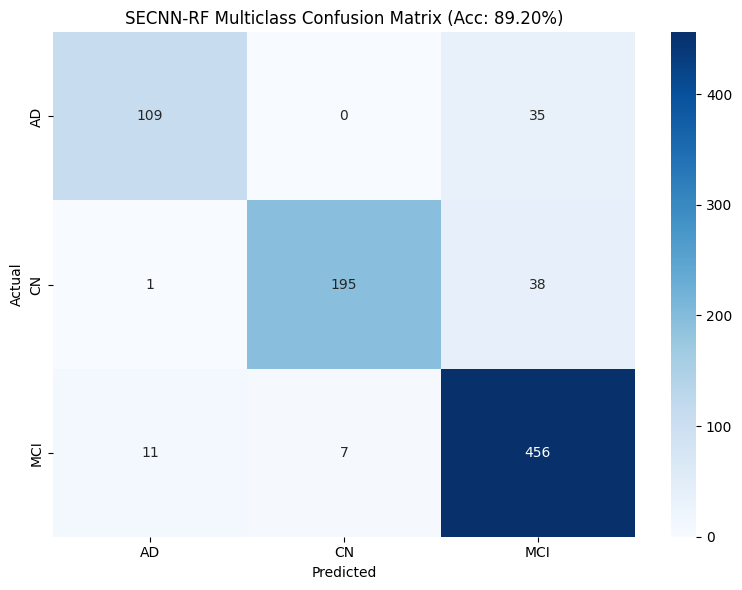

In [15]:
print("Classification Report (RF):")
print("="*60)
print(classification_report(y_test, rf_preds, target_names=CLASS_NAMES, digits=4))

precision, recall, f1, support = precision_recall_fscore_support(
    y_test, rf_preds, average=None, zero_division=0
)
macro_f1 = np.mean(f1)
weighted_f1 = np.average(f1, weights=support)
print(f"\nMacro F1: {macro_f1:.4f} | Weighted F1: {weighted_f1:.4f}")

cm = confusion_matrix(y_test, rf_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title(f'SECNN-RF Multiclass Confusion Matrix (Acc: {rf_acc*100:.2f}%)')
plt.tight_layout()
plt.savefig(os.path.join(CKPT_DIR, "cm_secnn_rf_multiclass.png"), dpi=150)
plt.show()

In [16]:
!pip install shap grad-cam

In [34]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import cv2
import shap
import os
from PIL import Image
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image
from lime import lime_image
from skimage.segmentation import mark_boundaries

def normalize_image(image_array):
    img = np.array(image_array, dtype=np.float32)
    img = img - np.min(img)
    if np.max(img) > 0: img = img / np.max(img)
    return img

def convert_to_rgb(image_array):
    if len(image_array.shape) == 2: return np.stack([image_array] * 3, axis=-1)
    elif image_array.shape[0] == 3: return np.transpose(image_array, (1, 2, 0))
    return image_array

def create_colormap_overlay(heatmap, image_array, alpha=0.4, colormap='jet'):
    heatmap = normalize_image(heatmap)
    image_array = normalize_image(image_array)
    if len(image_array.shape) == 2: image_array = convert_to_rgb(image_array)
    heatmap_colored = cv2.applyColorMap((heatmap * 255).astype(np.uint8), cv2.COLORMAP_JET)
    heatmap_colored = cv2.cvtColor(heatmap_colored, cv2.COLOR_BGR2RGB) / 255.0
    return (1 - alpha) * image_array + alpha * heatmap_colored

In [35]:
def compute_gradcam(model, image_tensor, target_class, device='cuda'):
    model = model.to(device)
    model.eval()
    conv_layers = [m for m in model.modules() if isinstance(m, nn.Conv2d)]
    
    cam = GradCAM(model=model, target_layers=[conv_layers[-1]])
    grayscale_cam = cam(
        input_tensor=image_tensor.to(device),
        targets=[ClassifierOutputTarget(target_class)],
        eigen_smooth=False, aug_smooth=False
    )
    
    with torch.no_grad():
        output = model(image_tensor.to(device))
        pred_prob = torch.softmax(output, dim=1)[0, target_class].item()
        pred_class = output.argmax(dim=1).item()
    
    return grayscale_cam[0], pred_class, pred_prob

def visualize_gradcam(image_array, grayscale_cam, pred_class, pred_prob, target_class, class_names, title):
    fig, axes = plt.subplots(1, 3, figsize=(14, 4))
    image_array = convert_to_rgb(normalize_image(image_array))
    grayscale_cam = normalize_image(grayscale_cam)
    
    axes[0].imshow(image_array, cmap='gray')
    axes[0].set_title('Original Image')
    axes[0].axis('off')
    
    im = axes[1].imshow(grayscale_cam, cmap='hot')
    axes[1].set_title('Grad-CAM Heatmap')
    axes[1].axis('off')
    plt.colorbar(im, ax=axes[1], fraction=0.046, pad=0.04)
    
    overlay = create_colormap_overlay(grayscale_cam, image_array, alpha=0.5)
    axes[2].imshow(overlay)
    axes[2].set_title(f'Overlay\n(Target: {class_names[target_class]}, Pred: {class_names[pred_class]} {pred_prob:.2%})')
    axes[2].axis('off')
    plt.suptitle(title, fontsize=14, fontweight='bold')
    plt.tight_layout()
    return fig

def compute_lime_explanation(model, image_array, target_class, device='cuda'):
    model = model.to(device)
    model.eval()
    image_array = convert_to_rgb(normalize_image(image_array))
    
    def predict_fn(images):
        imgs = torch.from_numpy(images).float().permute(0, 3, 1, 2).to(device)
        with torch.no_grad():
            return torch.softmax(model(imgs), dim=1).cpu().numpy()

    explainer = lime_image.LimeImageExplainer()
    explanation = explainer.explain_instance(
        image=image_array, classifier_fn=predict_fn, labels=[target_class], num_samples=500
    )
    image_and_mask = explanation.get_image_and_mask(label=target_class, positive_only=False, num_features=5, hide_rest=False)
    return explanation, image_and_mask

def visualize_lime(image_array, explanation, image_and_mask, target_class, class_names, title):
    image_array = convert_to_rgb(normalize_image(image_array))
    image, mask = image_and_mask
    fig, axes = plt.subplots(1, 2, figsize=(10, 5))
    
    axes[0].imshow(image_array)
    axes[0].set_title('Original Image')
    axes[0].axis('off')
    
    pos_image, _ = explanation.get_image_and_mask(target_class, positive_only=True, hide_rest=False)
    axes[1].imshow(mark_boundaries(pos_image, mask))
    axes[1].set_title(f'LIME Supporting Regions ({class_names[target_class]})')
    axes[1].axis('off')
    plt.suptitle(title, fontsize=14, fontweight='bold')
    plt.tight_layout()
    return fig


1. SHAP Analysis (Explaining the Random Forest)


/tmp/ipykernel_57/2770609741.py:10: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


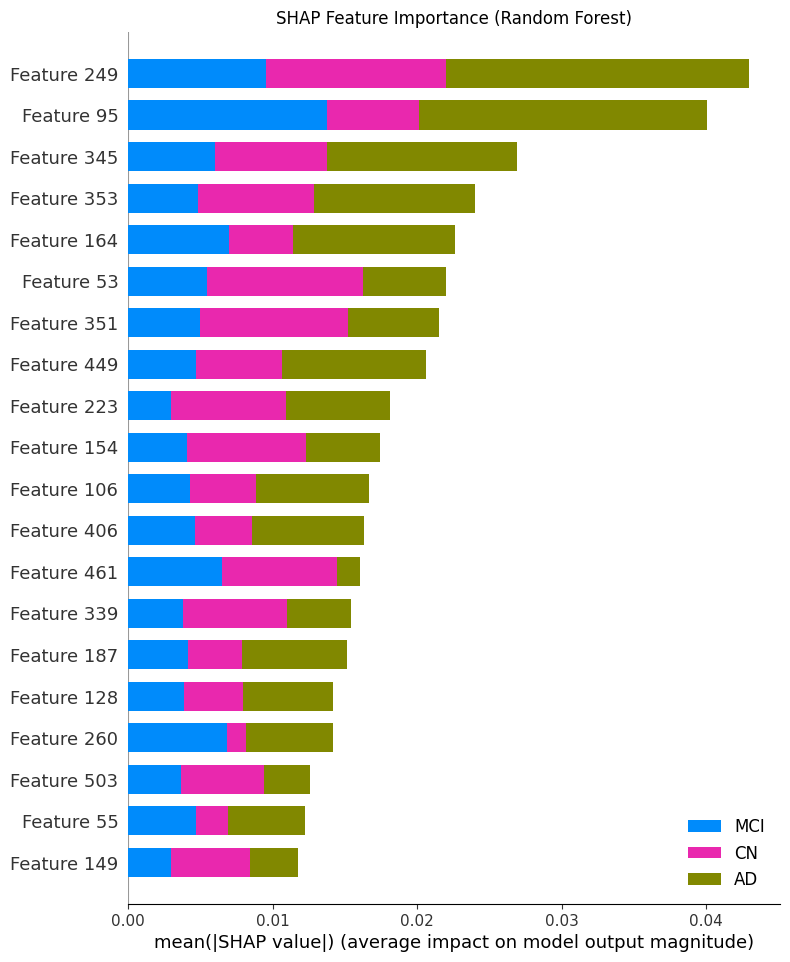

In [36]:
print("\n" + "="*60)
print("1. SHAP Analysis (Explaining the Random Forest)")
print("="*60)

explainer = shap.TreeExplainer(rf)
sample_idx = np.random.choice(X_test.shape[0], min(200, X_test.shape[0]), replace=False)
shap_values = explainer.shap_values(X_test[sample_idx])

plt.figure(figsize=(10, 6))
shap.summary_plot(
    shap_values, 
    X_test[sample_idx], 
    class_names=CLASS_NAMES, 
    plot_type="bar", 
    show=False
)
plt.title("SHAP Feature Importance (Random Forest)")
plt.savefig(os.path.join(CKPT_DIR, "shap_secnn_rf.png"), dpi=150)
plt.show()

In [61]:
print("Extracting New Random Test Samples...")

model.eval()
xai_samples = {}

temp_loader = torch.utils.data.DataLoader(test_loader.dataset, batch_size=1, shuffle=True)

for images, labels in temp_loader:
    lbl = labels[0].item()
    if lbl not in xai_samples:
        img_tensor = images.to(device)
        img_array = images[0].cpu().numpy()
        xai_samples[lbl] = (img_tensor, img_array)
    if len(xai_samples) == len(CLASS_NAMES): break

print(f"Successfully extracted {len(xai_samples)} NEW images (1 per class).")

Extracting New Random Test Samples...
Successfully extracted 3 NEW images (1 per class).



2. Grad-CAM (Explaining the SECNN)

--- Grad-CAM Class: AD ---


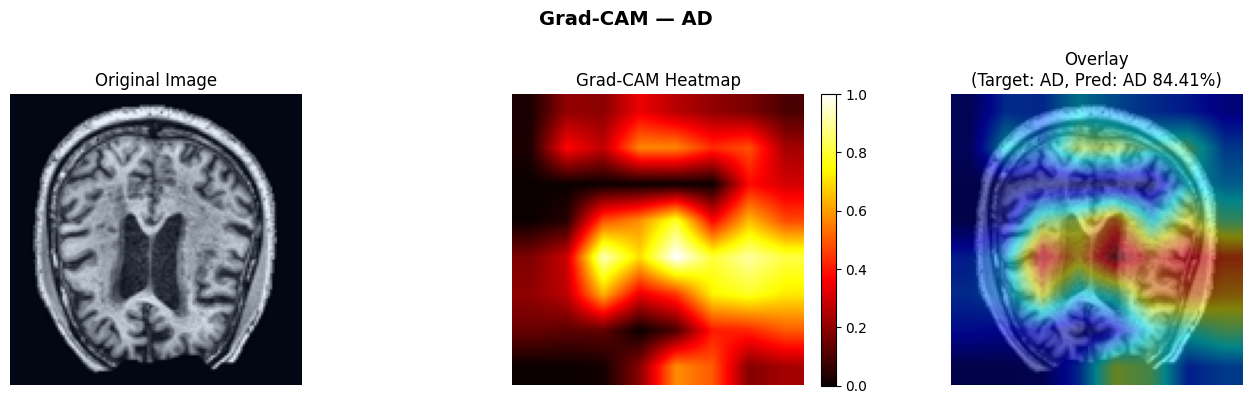


--- Grad-CAM Class: CN ---


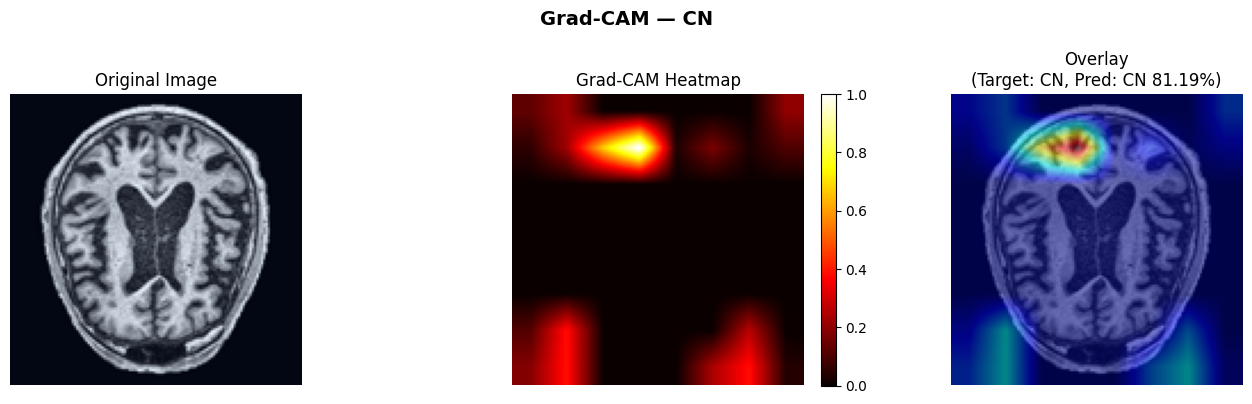


--- Grad-CAM Class: MCI ---


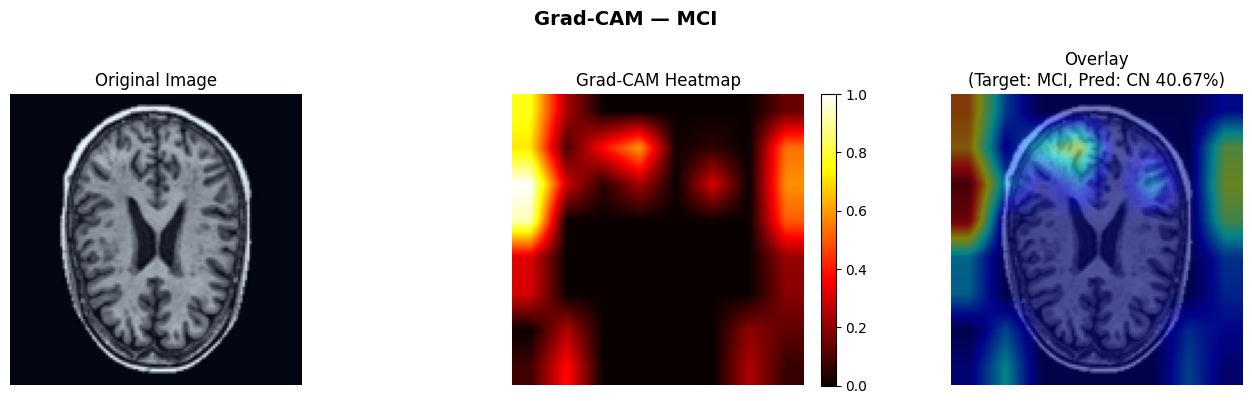

In [62]:
print("\n" + "="*60)
print("2. Grad-CAM (Explaining the SECNN)")
print("="*60)

for cls_idx in sorted(xai_samples):
    img_tensor, img_array = xai_samples[cls_idx]
    
    print(f'\n--- Grad-CAM Class: {CLASS_NAMES[cls_idx]} ---')
    cam, pred_class, pred_prob = compute_gradcam(model, img_tensor, cls_idx, device)
    fig_cam = visualize_gradcam(img_array, cam, pred_class, pred_prob, cls_idx, CLASS_NAMES, f'Grad-CAM — {CLASS_NAMES[cls_idx]}')
    plt.show()


3. LIME (Explaining the SECNN)

--- LIME Class: AD ---


  0%|          | 0/500 [00:00<?, ?it/s]

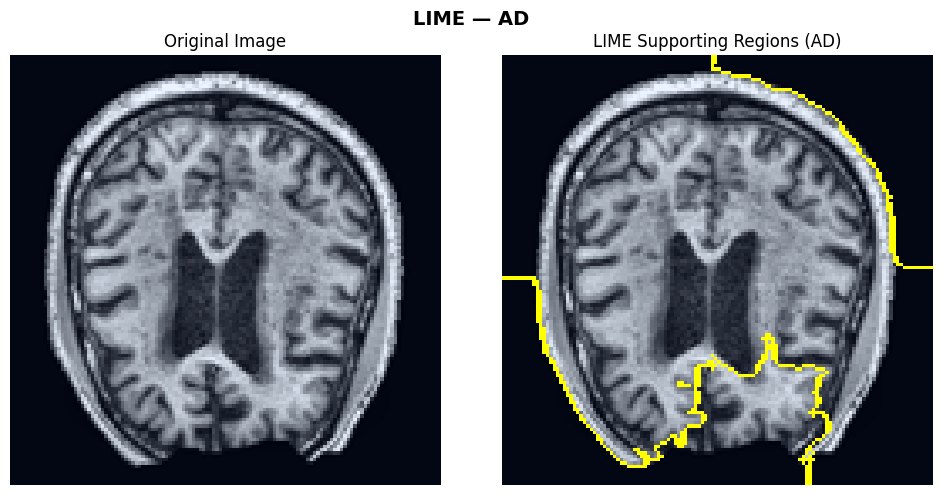


--- LIME Class: CN ---


  0%|          | 0/500 [00:00<?, ?it/s]

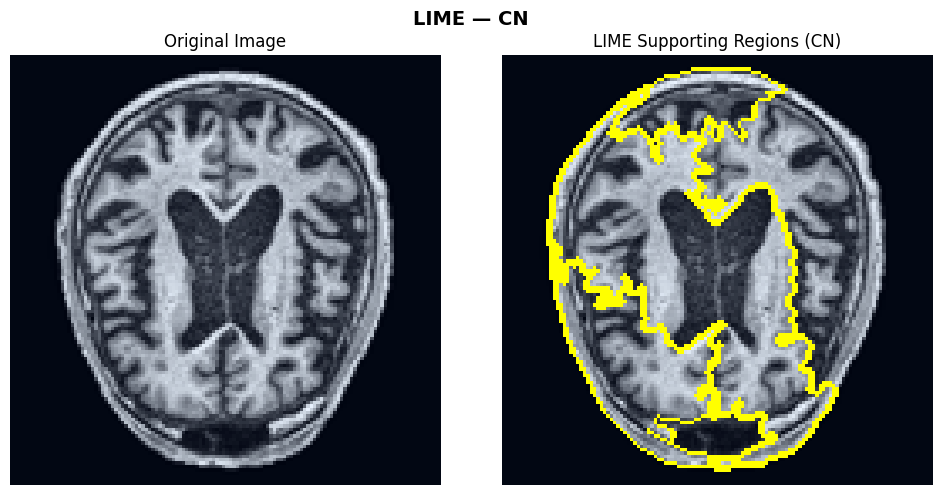


--- LIME Class: MCI ---


  0%|          | 0/500 [00:00<?, ?it/s]

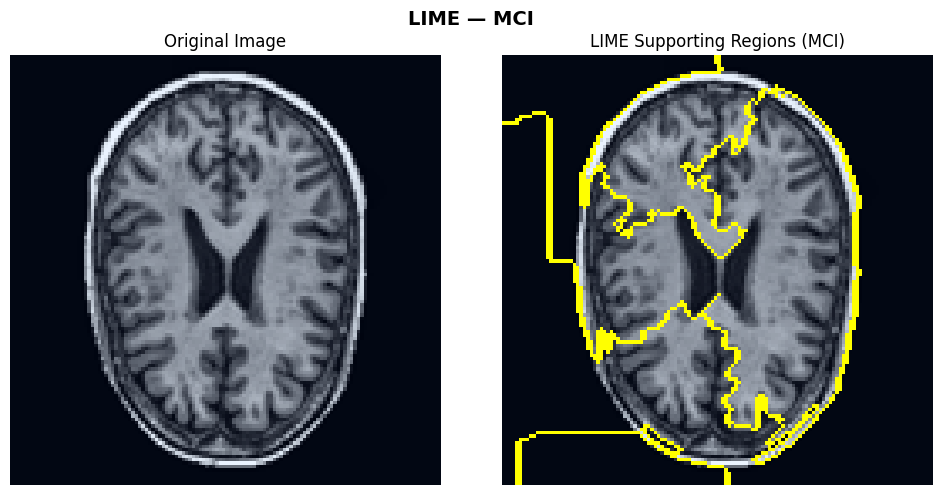

In [63]:
print("\n" + "="*60)
print("3. LIME (Explaining the SECNN)")
print("="*60)

for cls_idx in sorted(xai_samples):
    img_tensor, img_array = xai_samples[cls_idx]
    
    print(f'\n--- LIME Class: {CLASS_NAMES[cls_idx]} ---')
    explanation, img_and_mask = compute_lime_explanation(model, img_array, cls_idx, device)
    fig_lime = visualize_lime(img_array, explanation, img_and_mask, cls_idx, CLASS_NAMES, f'LIME — {CLASS_NAMES[cls_idx]}')
    plt.show()

3. t-SNE Analysis (Deep Feature Space Visualization)


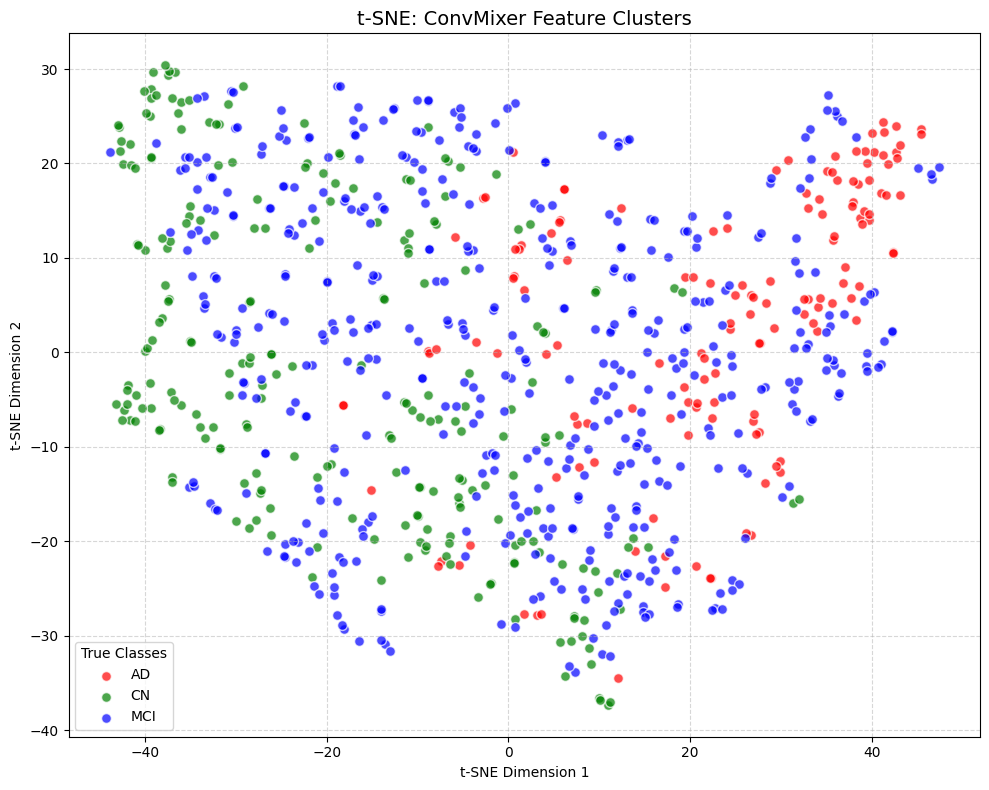

t-SNE plot saved.


In [21]:
from sklearn.manifold import TSNE

print("="*60)
print("3. t-SNE Analysis (Deep Feature Space Visualization)")
print("="*60)

tsne = TSNE(n_components=2, random_state=SEED, perplexity=30)
X_test_2d = tsne.fit_transform(X_test)

plt.figure(figsize=(10, 8))
colors = ['red', 'green', 'blue']
for i, class_name in enumerate(CLASS_NAMES):
    idx = (y_test == i)
    plt.scatter(X_test_2d[idx, 0], X_test_2d[idx, 1], 
                c=colors[i], label=class_name, alpha=0.7, edgecolors='w', s=50)

plt.title("t-SNE: ConvMixer Feature Clusters", fontsize=14)
plt.xlabel("t-SNE Dimension 1")
plt.ylabel("t-SNE Dimension 2")
plt.legend(title="True Classes")
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig(os.path.join(CKPT_DIR, "tsne_clusters.png"), dpi=150)
plt.show()
print("t-SNE plot saved.")

4. MDI Feature Importance (Inside the Decision Trees)


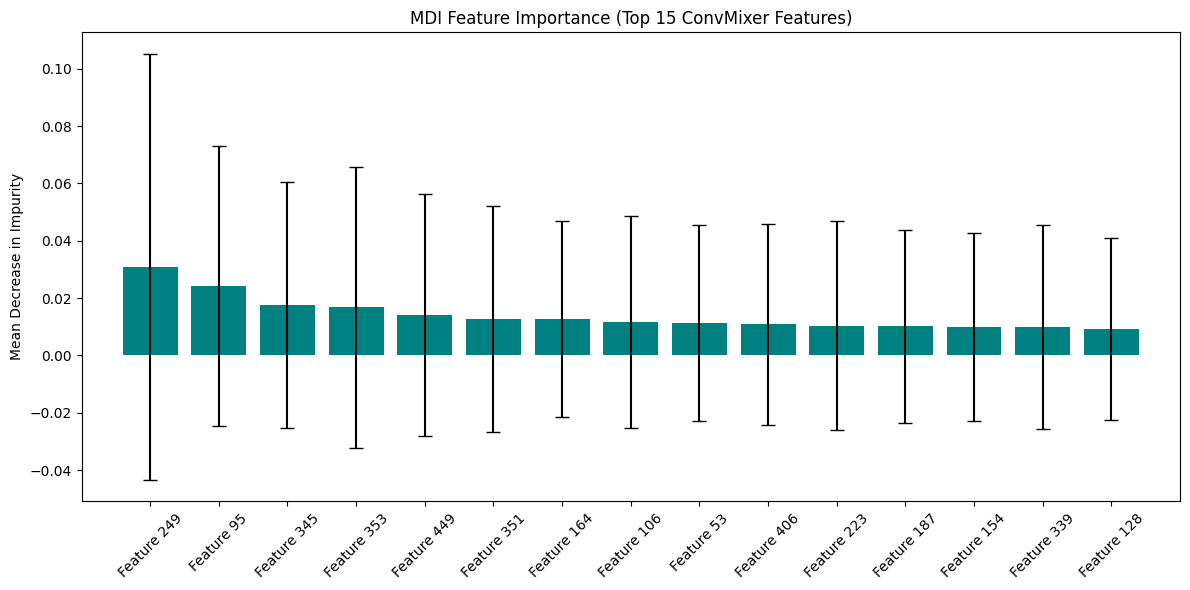

MDI Importance plot saved.


In [24]:
import pandas as pd

print("="*60)
print("4. MDI Feature Importance (Inside the Decision Trees)")
print("="*60)

importances = rf.feature_importances_
std = np.std([tree.feature_importances_ for tree in rf.estimators_], axis=0)

indices = np.argsort(importances)[::-1][:15]

plt.figure(figsize=(12, 6))
plt.title("MDI Feature Importance (Top 15 ConvMixer Features)")
plt.bar(range(15), importances[indices], color="teal", yerr=std[indices], align="center", capsize=5)

plt.xticks(range(15), [f"Feature {i}" for i in indices], rotation=45)
plt.xlim([-1, 15])
plt.ylabel("Mean Decrease in Impurity")
plt.tight_layout()
plt.savefig(os.path.join(CKPT_DIR, "mdi_importance.png"), dpi=150)
plt.show()
print("MDI Importance plot saved.")

In [65]:
import os
import shutil
from IPython.display import FileLink, display

print("="*60)
print("Packaging all files into a single ZIP...")
print("="*60)

import joblib
rf_save_path = os.path.join(CKPT_DIR, 'rf_model_final.pkl')
joblib.dump(rf, rf_save_path)

zip_path = "/kaggle/temp/all_project_outputs.zip"
os.makedirs("/kaggle/temp", exist_ok=True)
shutil.make_archive(zip_path.replace('.zip', ''), 'zip', '/kaggle/working')

final_zip_path = "/kaggle/working/all_project_outputs.zip"
shutil.move(zip_path, final_zip_path)

print("\n✅ Done! Click the link below to download everything in one file:")
display(FileLink("all_project_outputs.zip"))

Packaging all files into a single ZIP...

✅ Done! Click the link below to download everything in one file:


/kaggle/working/all_project_outputs.zip